# 02 - Weather Features
**Goal**: Fetch historical weather data for Flensburg, merge with heat demand, add time/holiday/school features, and explore correlations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import holidays

sns.set_theme(style='darkgrid')
%matplotlib inline

/Users/hervehuisman/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load Heat Demand Data

In [2]:
FILE = '../data/raw/flensburg_heat_network_2020_2024.xlsx'
df_heat = pd.read_excel(FILE, sheet_name=0, header=1)

TIMESTAMP_COL = df_heat.columns[0]
HEAT_COL = 'HKW Wärmeleistung\nGesamt'

df_heat[TIMESTAMP_COL] = pd.to_datetime(df_heat[TIMESTAMP_COL], errors='coerce')
df_heat = df_heat.dropna(subset=[TIMESTAMP_COL])
df_heat = df_heat.set_index(TIMESTAMP_COL).sort_index()
df_heat.index.name = 'timestamp'
df_heat[HEAT_COL] = pd.to_numeric(df_heat[HEAT_COL], errors='coerce')

demand = df_heat[[HEAT_COL]].rename(columns={HEAT_COL: 'heat_demand_mw'})
print(f'Heat demand: {demand.index.min()} -> {demand.index.max()}, {len(demand)} rows')

Heat demand: 2020-01-01 00:00:00 -> 2024-12-31 23:00:00, 43843 rows


## 2. Fetch Weather Data from Open-Meteo

In [3]:
def fetch_weather(start_date, end_date):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': 54.793,
        'longitude': 9.437,
        'start_date': start_date,
        'end_date': end_date,
        'hourly': ','.join([
            'temperature_2m',
            'wind_speed_10m',
            'wind_direction_10m',
            'shortwave_radiation',
            'relative_humidity_2m',
            'snowfall',
            'snow_depth',
            'cloud_cover'
        ]),
        'timezone': 'Europe/Berlin'
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()['hourly']
    df = pd.DataFrame(data)
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    df.index.name = 'timestamp'
    return df

print('Fetching weather data for Flensburg 2020-2024...')
weather = fetch_weather('2020-01-01', '2024-12-31')
print(f'Weather: {weather.index.min()} -> {weather.index.max()}, {len(weather)} rows')
weather.head()

Fetching weather data for Flensburg 2020-2024...
Weather: 2020-01-01 00:00:00 -> 2024-12-31 23:00:00, 43848 rows


,temperature_2m,wind_speed_10m,wind_direction_10m,shortwave_radiation,relative_humidity_2m,snowfall,snow_depth,cloud_cover
timestamp,,,,,,,,
2020-01-01 00:00:00,2.8,8.8,251,0.0,91,0.0,0.0,68
2020-01-01 01:00:00,3.6,9.5,245,0.0,90,0.0,0.0,58
2020-01-01 02:00:00,2.7,10.8,244,0.0,93,0.0,0.0,42
2020-01-01 03:00:00,2.9,10.8,255,0.0,93,0.0,0.0,34
2020-01-01 04:00:00,2.9,11.8,250,0.0,92,0.0,0.0,40


## 3. Merge Heat Demand and Weather

In [4]:
demand.index = demand.index.tz_localize(None)
weather.index = weather.index.tz_localize(None)

df = demand.join(weather, how='inner')
df.columns = ['heat_demand_mw', 'temperature_c', 'wind_speed_ms', 'wind_direction_deg',
              'solar_radiation_wm2', 'humidity_pct', 'snowfall_cm', 'snow_depth_m', 'cloud_cover_pct']
print(f'Merged: {len(df)} rows')
df.head()

Merged: 43843 rows


,heat_demand_mw,temperature_c,wind_speed_ms,wind_direction_deg,solar_radiation_wm2,humidity_pct,snowfall_cm,snow_depth_m,cloud_cover_pct
timestamp,,,,,,,,,
2020-01-01 00:00:00,188.732,2.8,8.8,251,0.0,91,0.0,0.0,68
2020-01-01 01:00:00,195.986,3.6,9.5,245,0.0,90,0.0,0.0,58
2020-01-01 02:00:00,188.400,2.7,10.8,244,0.0,93,0.0,0.0,42
2020-01-01 03:00:00,170.277,2.9,10.8,255,0.0,93,0.0,0.0,34
2020-01-01 04:00:00,174.004,2.9,11.8,250,0.0,92,0.0,0.0,40


## 4. Add All Features

In [5]:
# --- Time features ---
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['day_of_year'] = df.index.dayofyear
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)

# --- Public holidays ---
de_holidays = holidays.Germany(state='SH', years=range(2020, 2025))
df['is_holiday'] = df.index.normalize().map(lambda d: 1 if d in de_holidays else 0)

# --- School holidays Schleswig-Holstein (hardcoded from official state calendar) ---
sh_school_holidays = [
    # 2020
    ('2020-01-01', '2020-01-03'), ('2020-04-06', '2020-04-18'), ('2020-05-21', '2020-05-21'),
    ('2020-06-29', '2020-08-08'), ('2020-10-05', '2020-10-17'), ('2020-12-21', '2020-12-31'),
    # 2021
    ('2021-01-01', '2021-01-05'), ('2021-03-29', '2021-04-09'), ('2021-05-13', '2021-05-13'),
    ('2021-06-28', '2021-08-07'), ('2021-10-04', '2021-10-16'), ('2021-12-23', '2021-12-31'),
    # 2022
    ('2022-01-01', '2022-01-03'), ('2022-04-11', '2022-04-23'), ('2022-05-26', '2022-05-26'),
    ('2022-06-27', '2022-08-06'), ('2022-10-10', '2022-10-21'), ('2022-12-22', '2022-12-31'),
    # 2023
    ('2023-01-01', '2023-01-05'), ('2023-04-03', '2023-04-14'), ('2023-05-18', '2023-05-18'),
    ('2023-06-26', '2023-08-05'), ('2023-10-02', '2023-10-13'), ('2023-12-22', '2023-12-31'),
    # 2024
    ('2024-01-01', '2024-01-05'), ('2024-03-25', '2024-04-05'), ('2024-05-09', '2024-05-10'),
    ('2024-06-24', '2024-08-03'), ('2024-10-04', '2024-10-18'), ('2024-12-19', '2024-12-31'),
]

school_holiday_dates = set()
for start, end in sh_school_holidays:
    for d in pd.date_range(start, end):
        school_holiday_dates.add(d.date())

df['is_school_holiday'] = df.index.normalize().map(lambda d: 1 if d.date() in school_holiday_dates else 0)

# --- Wind direction (sine/cosine encoding) ---
wind_rad = np.deg2rad(df['wind_direction_deg'])
df['wind_sin'] = np.sin(wind_rad)
df['wind_cos'] = np.cos(wind_rad)

# --- Temperature change rate (how fast temp is dropping) ---
df['temp_change_3h'] = df['temperature_c'].diff(3)   # change over last 3 hours

# --- Heating degree hours (non-linear cold signal) ---
df['heating_degrees'] = (15 - df['temperature_c']).clip(lower=0)

# --- Cumulative heating degree days since Oct 1 (seasonal thermal momentum) ---
df['heating_season_day'] = df.apply(
    lambda r: (r.name - pd.Timestamp(f"{r.name.year if r.name.month >= 10 else r.name.year - 1}-10-01")).days,
    axis=1
).clip(lower=0)

print('All features added.')
print(f'School holiday hours: {df["is_school_holiday"].sum()} ({df["is_school_holiday"].sum()/len(df)*100:.1f}%)')
print(f'Snow depth > 0: {(df["snow_depth_m"] > 0).sum()} hours ({(df["snow_depth_m"] > 0).sum()/len(df)*100:.1f}%)')

All features added.
School holiday hours: 9887 (22.6%)
Snow depth > 0: 3129 hours (7.1%)


## 5. Correlation Matrix

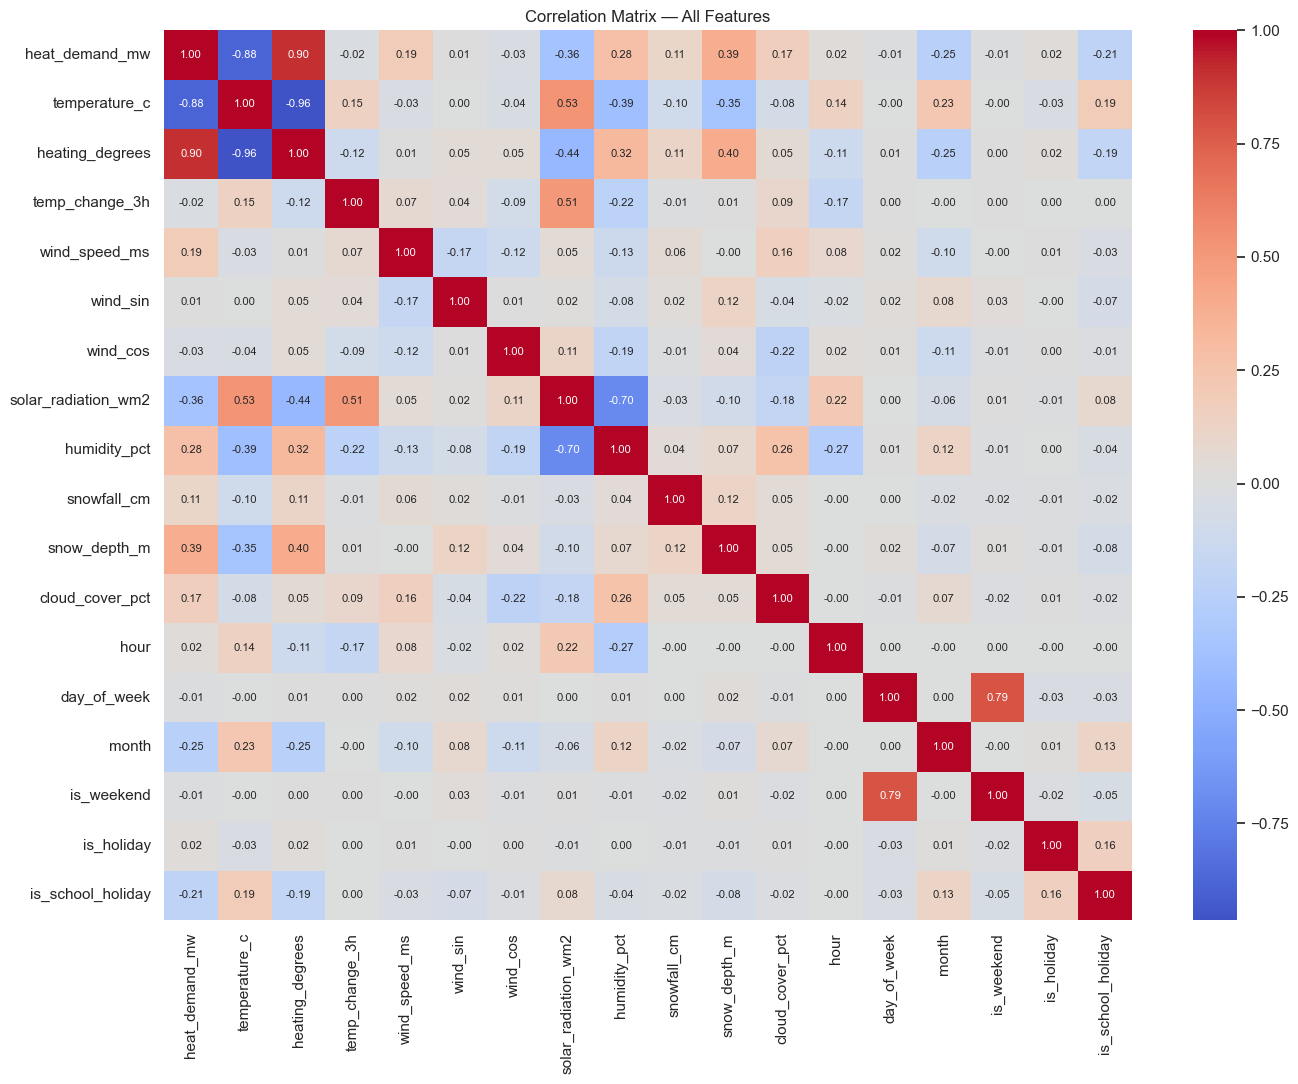

In [6]:
features = ['heat_demand_mw','temperature_c','heating_degrees','temp_change_3h',
            'wind_speed_ms','wind_sin','wind_cos','solar_radiation_wm2',
            'humidity_pct','snowfall_cm','snow_depth_m','cloud_cover_pct',
            'hour','day_of_week','month','is_weekend','is_holiday','is_school_holiday']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — All Features')
plt.tight_layout()
plt.show()

## 6. School Holiday Effect

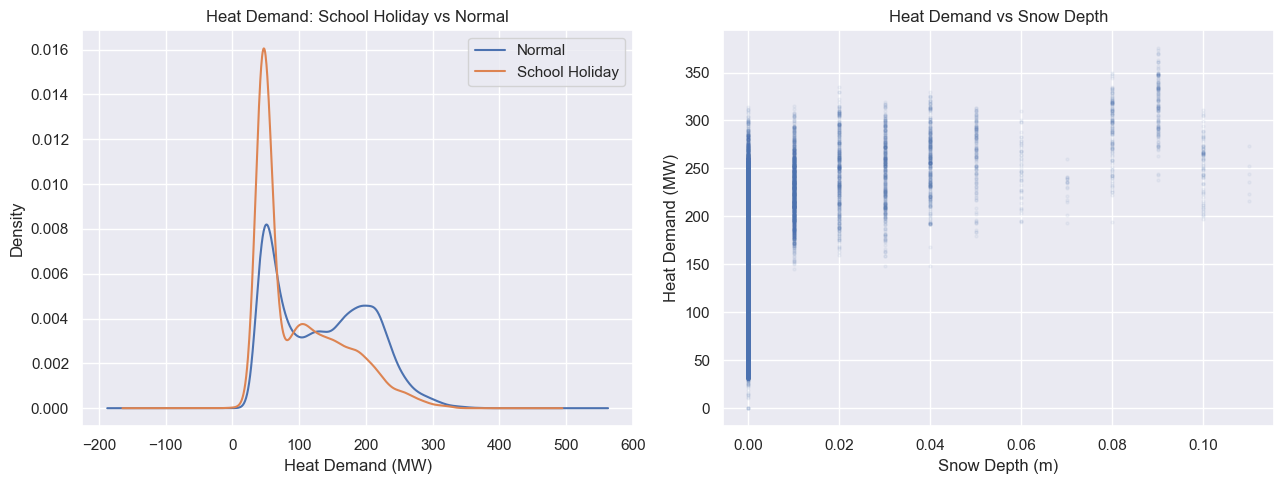

Mean demand - normal days:         135.81 MW
Mean demand - school holidays:     99.59 MW


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# School holiday vs normal
df.groupby('is_school_holiday')['heat_demand_mw'].plot(kind='density', ax=axes[0])
axes[0].set_title('Heat Demand: School Holiday vs Normal')
axes[0].set_xlabel('Heat Demand (MW)')
axes[0].legend(['Normal', 'School Holiday'])

# Snow depth vs demand
axes[1].scatter(df['snow_depth_m'], df['heat_demand_mw'], alpha=0.05, s=5)
axes[1].set_xlabel('Snow Depth (m)')
axes[1].set_ylabel('Heat Demand (MW)')
axes[1].set_title('Heat Demand vs Snow Depth')

plt.tight_layout()
plt.show()

print('Mean demand - normal days:        ', df[df['is_school_holiday']==0]['heat_demand_mw'].mean().round(2), 'MW')
print('Mean demand - school holidays:    ', df[df['is_school_holiday']==1]['heat_demand_mw'].mean().round(2), 'MW')

## 7. Save Enriched Dataset

In [8]:
df.to_csv('../data/processed/demand_with_weather.csv')
print('Saved to data/processed/demand_with_weather.csv')
print('Columns:', df.columns.tolist())

Saved to data/processed/demand_with_weather.csv
Columns: ['heat_demand_mw', 'temperature_c', 'wind_speed_ms', 'wind_direction_deg', 'solar_radiation_wm2', 'humidity_pct', 'snowfall_cm', 'snow_depth_m', 'cloud_cover_pct', 'hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_holiday', 'is_school_holiday', 'wind_sin', 'wind_cos', 'temp_change_3h', 'heating_degrees', 'heating_season_day']
